TAREA 4

In [18]:

!pip install --quiet tensorflow==2.10.0 tensorflow_datasets==4.9.2 keras==2.10.0 numpy==1.23.5 matplotlib==3.7.1 seaborn==0.13.2 scikit-learn==1.4.1.post1 pillow==9.4.0


ERROR: Could not find a version that satisfies the requirement tensorflow==2.10.0 (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.0.post1, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.20.0rc0)
ERROR: No matching distribution found for tensorflow==2.10.0


In [2]:
# CELDA 2 - Imports y verificación de entorno
import os
import math
import pathlib
import datetime
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# CELDA 3 - Configuración básica
AUTO = tf.data.AUTOTUNE
IMG_SIZE = (224, 224)       # tamaño típico para MobileNetV2
BATCH_SIZE = 32
EPOCHS = 15
WEIGHT_DECAY = 1e-4
LEARNING_RATE = 1e-3
DATASET_NAME = 'tf_flowers' # dataset de ejemplo de TFDS


In [4]:
# CELDA 4 - Cargar dataset con split train/val
(ds_train, ds_val), ds_info = tfds.load(
    DATASET_NAME,
    split=['train[:85%]', 'train[85%:]'],
    with_info=True,
    as_supervised=True,
)

NUM_CLASSES = ds_info.features['label'].num_classes
print('Dataset:', DATASET_NAME)
print('Num classes:', NUM_CLASSES)
print('Dataset info:', ds_info)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.RQO8RW_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Dataset: tf_flowers
Num classes: 5
Dataset info: tfds.core.DatasetInfo(
    name='tf_flowers',
    full_name='tf_flowers/3.0.1',
    description="""
    A large set of images of flowers
    """,
    homepage='https://www.tensorflow.org/tutorials/load_data/images',
    data_dir='/root/tensorflow_datasets/tf_flowers/3.0.1',
    file_format=tfrecord,
    download_size=218.21 MiB,
    dataset_size=221.83 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=3670, num_shards=2>,
    },
    citation="""@ONLINE {tfflowers,
    author = "The TensorFlow Team",
    title = "Flowers",
    month = "jan",


In [5]:
# CELDA 5 - Preprocesamiento y aumentación
def preprocess_image(image, label, img_size=IMG_SIZE):
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def preprocess_train(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    image = data_augmentation(image)
    return image, label


In [6]:
# CELDA 6 - Preparar datasets
train_ds = ds_train.map(preprocess_train, num_parallel_calls=AUTO)
train_ds = train_ds.shuffle(1024).batch(BATCH_SIZE).cache().prefetch(AUTO)

val_ds = ds_val.map(preprocess_image, num_parallel_calls=AUTO)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(AUTO)

# Verificar un batch
for images, labels in train_ds.take(1):
    print('Train batch image shape:', images.shape)
    print('Train batch labels shape:', labels.shape)


Train batch image shape: (32, 224, 224, 3)
Train batch labels shape: (32,)


In [7]:
# CELDA 7 - Modelo base MobileNetV2
base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
# CELDA 8 - Compilar
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# CELDA 9 - Callbacks
now = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
checkpoint_path = f"/content/model_checkpoint_{now}.h5"

es = callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
mc = callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)
lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)


In [10]:
# CELDA 10 - Entrenamiento inicial
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[es, mc, lr]
)


Epoch 1/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.6845 - loss: 0.8504

98/98 ━━━━━━━━━━━━━━━━━━━━ 68s 422ms/step - accuracy: 0.6855 - loss: 0.8479 - val_accuracy: 0.8618 - val_loss: 0.3517 - learning_rate: 0.0010
Epoch 2/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.8731 - loss: 0.3410 - val_accuracy: 0.8745 - val_loss: 0.3526 - learning_rate: 0.0010
Epoch 3/15
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9038 - loss: 0.2716

98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9038 - loss: 0.2714 - val_accuracy: 0.8891 - val_loss: 0.3158 - learning_rate: 0.0010
Epoch 4/15
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9148 - loss: 0.2263

98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9149 - loss: 0.2262 - val_accuracy: 0.8909 - val_loss: 0.3146 - learning_rate: 0.0010
Epoch 5/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9291 - loss: 0.2089 - val_accuracy: 0.8964 - val_loss: 0.3270 - learning_rate: 0.0010
Epoch 6/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9325 - loss: 0.1719 - val_accuracy: 0.8909 - val_loss: 0.3482 - learning_rate: 0.0010
Epoch 7/15
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9466 - loss: 0.1432

98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9466 - loss: 0.1430 - val_accuracy: 0.9036 - val_loss: 0.2902 - learning_rate: 5.0000e-04
Epoch 8/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9649 - loss: 0.1100 - val_accuracy: 0.9000 - val_loss: 0.3014 - learning_rate: 5.0000e-04
Epoch 9/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9750 - loss: 0.0889 - val_accuracy: 0.8945 - val_loss: 0.3167 - learning_rate: 5.0000e-04
Epoch 10/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9741 - loss: 0.0825 - val_accuracy: 0.8964 - val_loss: 0.2902 - learning_rate: 2.5000e-04
Epoch 11/15
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9754 - loss: 0.0745

98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9754 - loss: 0.0744 - val_accuracy: 0.8982 - val_loss: 0.2865 - learning_rate: 2.5000e-04
Epoch 12/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9774 - loss: 0.0673 - val_accuracy: 0.9055 - val_loss: 0.3003 - learning_rate: 2.5000e-04
Epoch 13/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9824 - loss: 0.0544 - val_accuracy: 0.8964 - val_loss: 0.2942 - learning_rate: 2.5000e-04
Epoch 14/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9819 - loss: 0.0631 - val_accuracy: 0.8964 - val_loss: 0.2948 - learning_rate: 1.2500e-04
Epoch 15/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9892 - loss: 0.0489 - val_accuracy: 0.8927 - val_loss: 0.3166 - learning_rate: 1.2500e-04


In [11]:
# CELDA 11 - Fine-tuning
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE * 0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 2,190,661 (8.36 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [12]:
# CELDA 12 - Entrenamiento final
fine_tune_epochs = 10
total_epochs = EPOCHS + fine_tune_epochs
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history1.epoch[-1] + 1 if hasattr(history1, 'epoch') else EPOCHS,
    callbacks=[es, mc, lr]
)


Epoch 16/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 197ms/step - accuracy: 0.8315 - loss: 0.5159 - val_accuracy: 0.9055 - val_loss: 0.3333 - learning_rate: 1.0000e-04
Epoch 17/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.9876 - loss: 0.0473 - val_accuracy: 0.9273 - val_loss: 0.3040 - learning_rate: 1.0000e-04
Epoch 18/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9975 - loss: 0.0176 - val_accuracy: 0.9273 - val_loss: 0.3262 - learning_rate: 1.0000e-04
Epoch 19/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9994 - loss: 0.0070 - val_accuracy: 0.9327 - val_loss: 0.3185 - learning_rate: 1.0000e-04
Epoch 20/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 0.9327 - val_loss: 0.3226 - learning_rate: 5.0000e-05
Epoch 21/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9992 - loss: 0.0048 - val_accuracy: 0.9327 - val_loss: 0.3072 - learning_rate: 5.0000e-05


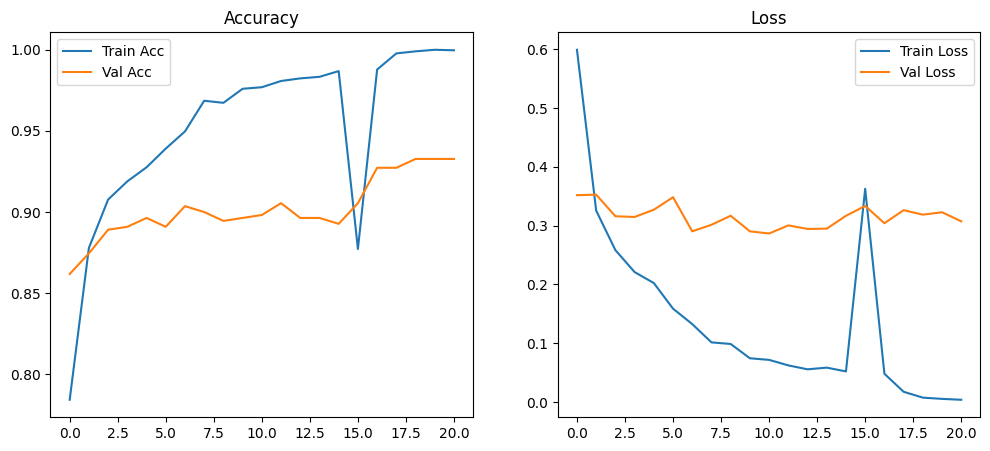

In [13]:
# CELDA 13 - Graficar resultados
acc = history1.history.get('accuracy', []) + history2.history.get('accuracy', [])
val_acc = history1.history.get('val_accuracy', []) + history2.history.get('val_accuracy', [])
loss = history1.history.get('loss', []) + history2.history.get('loss', [])
val_loss = history1.history.get('val_loss', []) + history2.history.get('val_loss', [])

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()


In [14]:
# CELDA 14 - Evaluación final
eval_results = model.evaluate(val_ds)
print('Eval results (loss, acc):', eval_results)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9205 - loss: 0.3886
Eval results (loss, acc): [0.30395299196243286, 0.9272727370262146]


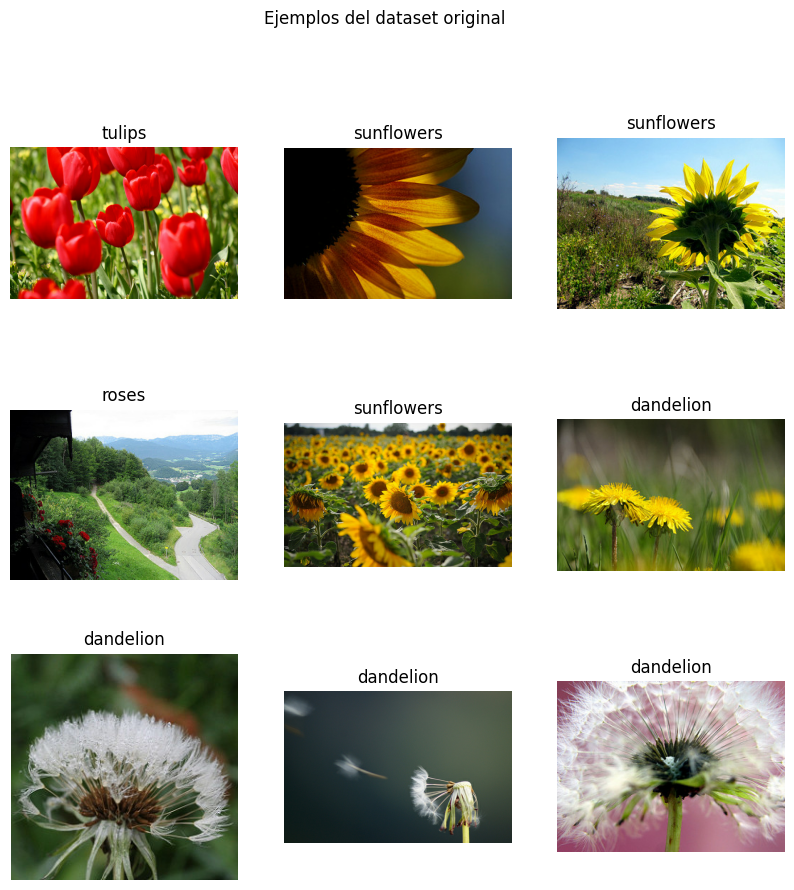

In [15]:
# CELDA 16 - Visualizar imágenes originales del dataset con sus etiquetas reales

# Obtener nombres de las clases
class_names = ds_info.features['label'].names

plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(ds_train.take(9)):  # tomar 9 imágenes
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")
plt.suptitle("Ejemplos del dataset original")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


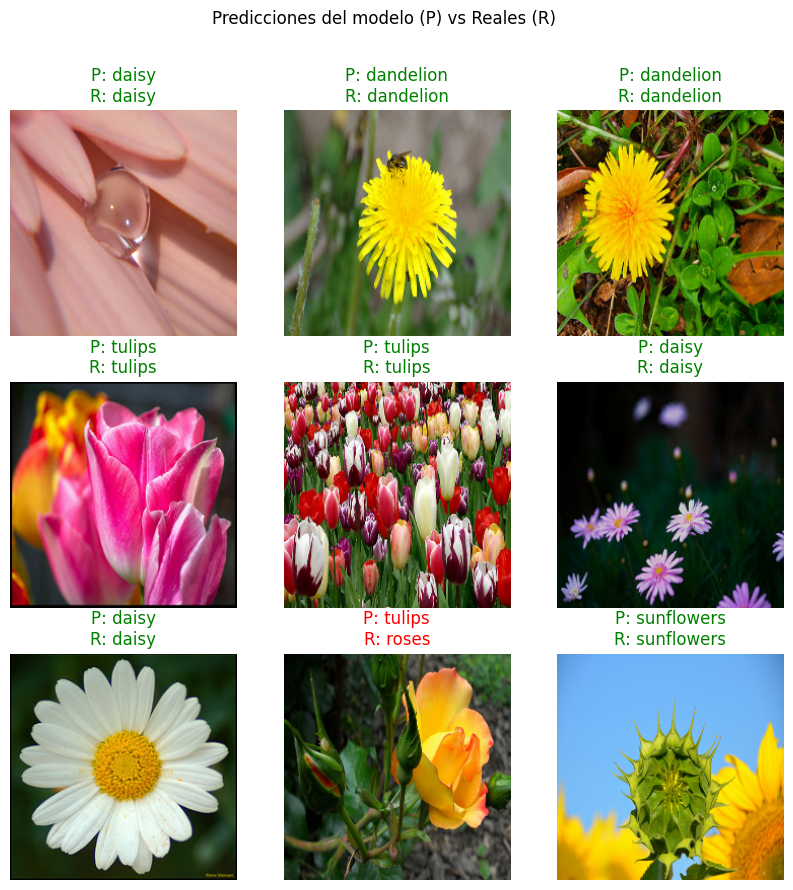

In [16]:
# CELDA 17 - Visualizar predicciones del modelo sobre imágenes de validación

import random

# Tomar un batch de validación
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    pred_labels = tf.argmax(preds, axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        true_label = class_names[labels[i]]
        predicted_label = class_names[pred_labels[i]]

        color = "green" if predicted_label == true_label else "red"
        plt.title(f"P: {predicted_label}\nR: {true_label}", color=color)
        plt.axis("off")
    plt.suptitle("Predicciones del modelo (P) vs Reales (R)")
    plt.show()
